# **M2 Phase: Targeted EDA and Unsupervised Machine Learning for Grant "Era" Analysis**
**US Government Grant Opportunities Dataset**

By: Anna Baldzikowski


BA820 A1, Team 11

##**Domain Question:**

How have grant opportunity characteristics (agency, estimated funding, year posted, eligibility, category) evolved over time, and do distinct policy-era archetypes emerge in modern federal grantmaking?

*Based on and modified from question 2 in M1*

## **Problem Statement:**

This analysis dives into if there are any time-bound "eras" of US government grants that unsupervised machine learning clustering detects. The model will use features of agency, estimated funding, year posted, eligibility, and category. I will be seeing if clusters emerge that are separated based on years. First, I will conduct Python EDA to explore preliminary trends over time. Then, I will dive into unsupervised machine learning with K-means clustering.

Because the Grants table alone primarily captures administrative scale rather than policy priorities, my analysis incorporates eligibility and category features from the Details table despite significantly reduced rows. This is a trade-off I decided to make, as my model would not contain enough fruitful features/dimensions without these. (More details in EDA 1.)

## **Upload data to Colab**

In [3]:
import pandas as pd

grants = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv"
)

details = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grant_opportunity_details.csv"
)


/tmp/ipython-input-1792275738.py:3: DtypeWarning: Columns (6,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  grants = pd.read_csv(


## **Additional EDA: Pre-Clustering**

The EDA in this notebook will focus on discovering patterns relating to time periods of grants. It will also focus on understanding the features that will be used in clustering (like agency, funding, eligibility, category).

### **1. Dataset Structure and Coverage**

**Grants Table:**

In [4]:
grants.shape

(74669, 17)

In [5]:
grants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74669 entries, 0 to 74668
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   opportunity_id                  74669 non-null  int64  
 1   opportunity_number              74669 non-null  object 
 2   opportunity_title               74669 non-null  object 
 3   agency_code                     74626 non-null  object 
 4   agency_name                     74625 non-null  object 
 5   estimated_funding               53043 non-null  float64
 6   expected_number_of_awards       53371 non-null  object 
 7   grantor_contact                 74638 non-null  object 
 8   agency_contact_phone            668 non-null    object 
 9   agency_contact_email            73791 non-null  object 
 10  estimated_post_date             517 non-null    object 
 11  estimated_application_due_date  574 non-null    object 
 12  posted_date                     

**Details Table:**

In [6]:
details.shape

(2000, 68)

In [7]:
details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 68 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   opportunity_id                                                       2000 non-null   int64  
 1   funding_opportunity_number                                           2000 non-null   object 
 2   funding_opportunity_title                                            2000 non-null   object 
 3   opportunity_category                                                 2000 non-null   object 
 4   opportunity_category_explanation                                     53 non-null     object 
 5   expected_number_of_awards                                            619 non-null    float64
 6   cost_sharing_or_matching_requirement                                 2000 non-null   bool   
 7   versio

In [8]:
# Merge the tables
merged = grants.merge(details, on='opportunity_id', how='inner')

print("Merged rows:", len(merged))

# Just create posted_year for checking temporal coverage
merged['posted_year'] = pd.to_datetime(merged['posted_date_y']).dt.year

print("\nYear range in merged data:")
print(merged['posted_year'].agg(['min', 'max', 'count']))

print("\nYear distribution:")
print(merged['posted_year'].value_counts().sort_index())

print("\nAgency distribution (top 10):")
print(merged['agency_name_y'].value_counts().head(10))

# Check category columns
category_cols = [col for col in merged.columns if col.startswith('category_')]
print("\nNumber of category columns:", len(category_cols))

# Check eligibility columns
eligibility_cols = [col for col in merged.columns if col.startswith('eligibility_')]
print("Number of eligibility columns:", len(eligibility_cols))

Merged rows: 2000

Year range in merged data:
min      2004
max      2023
count    2000
Name: posted_year, dtype: int64

Year distribution:
posted_year
2004       1
2007       2
2008       2
2009       9
2010       5
2011       7
2012       7
2013       3
2014       7
2015      17
2016      10
2017      10
2018      38
2019      28
2020     125
2021     306
2022     400
2023    1023
Name: count, dtype: int64

Agency distribution (top 10):
agency_name_y
National Institutes of Health                       967
National Science Foundation                         276
Department of Commerce                               45
Dept. of the Army -- USAMRAA                         44
NASA Headquarters                                    43
Agency for International Development                 42
Environmental Protection Agency                      40
Fish and Wildlife Service                            27
National Energy Technology Laboratory                25
Centers for Disease Control and Prevent

In [9]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 85 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   opportunity_id                                                       2000 non-null   int64  
 1   opportunity_number                                                   2000 non-null   object 
 2   opportunity_title                                                    2000 non-null   object 
 3   agency_code                                                          2000 non-null   object 
 4   agency_name_x                                                        2000 non-null   object 
 5   estimated_funding                                                    685 non-null    float64
 6   expected_number_of_awards_x                                          619 non-null    object 
 7   granto

**Analysis and note on modification to original domain question 2:**
Deciding what tables and features to use took significant consideration. At first, I only wanted to use the Grants table as it has ~75,000 rows versus only 2000 rows in the Details table, and merging the two would eliminate the consideration of many grants in a ML model. Furthermore, as seen above, the Details table is skewed toward grants in more recent years.

However, when selecting features to see if time-bound "eras" of funding emerge with unsupervised ML, I came to find that the Grants table did not include enough fruitful features to honor the question. For instance, I first planned to only use agency, estimated funding, expected number of awards, date posted, and days open (calculated field) - all from the Grants table. However, these features mainly capture administrative scale, not policy priorities. The Details table is needed to accurately evaluate if "eras" emerge, even though merging the tables makes the dataset smaller.

**(Former (M1) Version: Domain Question 2:** How have grant opportunity characteristics (funding magnitude, eligibility, and agency participation) evolved over time, and do distinct “eras” of federal grant-making emerge?).

The 3 tables I can work with in EDA:

*   Grants (big picture)
*   Details (descriptive data like eligibility and category)
*   Merged (my inner-join of the 2^, which I will conduct unsupervised ML on)

###**2. EDA exploring timelines of grants and their funding**

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

### **2.1. What are the number of grants over time, by date posted and date closed? (using larger Grants table)**

I will dive into number of grants over time. This was analyzed in the M1 EDA, but I am diving deeper by plotting "time" not only by "posted_date" but also by "close_date."

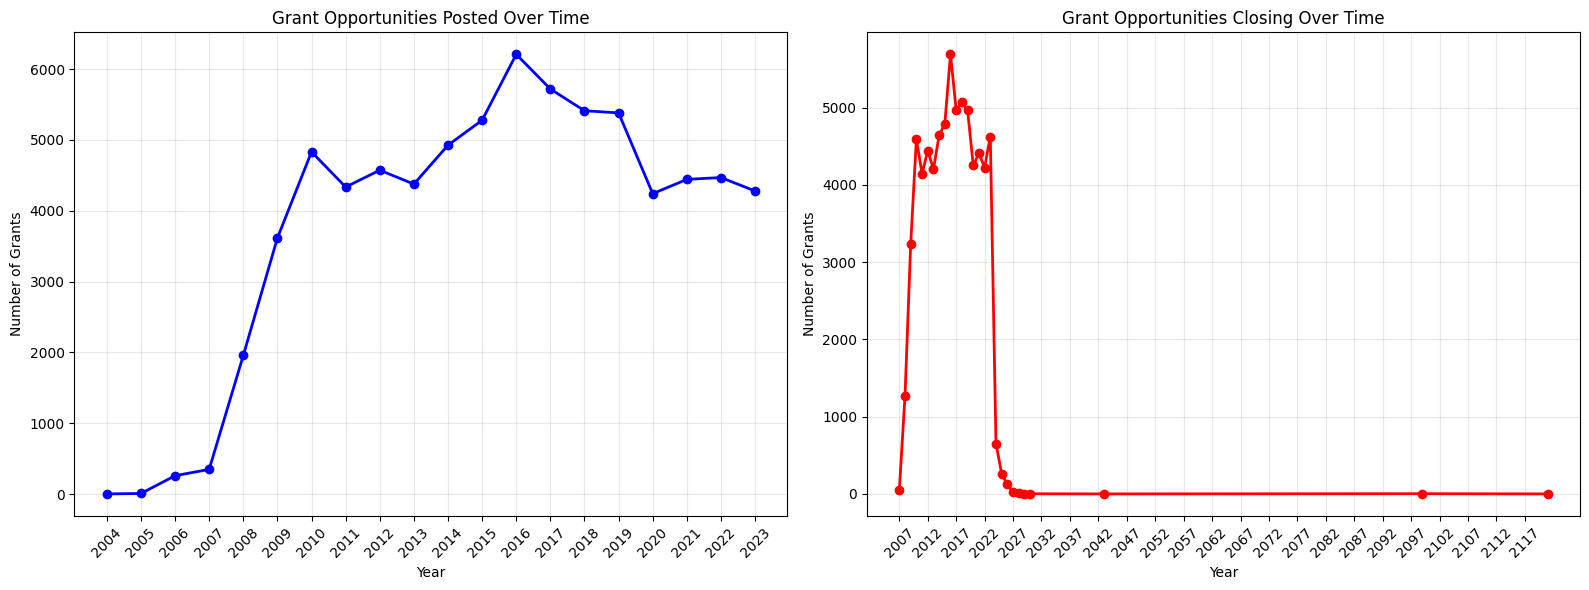

In [11]:
# Convert dates to years
grants['posted_year'] = pd.to_datetime(grants['posted_date'], errors='coerce').dt.year
grants['close_year'] = pd.to_datetime(grants['close_date'], errors='coerce').dt.year

# Count and sort grants by year
posted_by_year = grants['posted_year'].value_counts().sort_index()
closed_by_year = grants['close_year'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Posted dates subplot
ax1.plot(posted_by_year.index, posted_by_year.values,
         marker='o', linewidth=2, color='blue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Grants')
ax1.set_title('Grant Opportunities Posted Over Time')
ax1.grid(True, alpha=0.3)

# Set x-axis to show all years as integers
min_posted = int(posted_by_year.index.min())
max_posted = int(posted_by_year.index.max())
ax1.set_xticks(range(min_posted, max_posted + 1))
ax1.tick_params(axis='x', rotation=45)

# Close dates subplot
ax2.plot(closed_by_year.index, closed_by_year.values,
         marker='o', linewidth=2, color='red')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Grants')
ax2.set_title('Grant Opportunities Closing Over Time')
ax2.grid(True, alpha=0.3)

# Show x-ticks every 5 years for close dates-- was too crowded showing all years
min_closed = int(closed_by_year.index.min())
max_closed = int(closed_by_year.index.max())
ax2.set_xticks(range(min_closed, max_closed + 1, 5))  # Every 5 years
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Analysis:** The graph on the left, included in our M1 EDA, is complemented by the closing patterns of grants to get a deeper insight into grant timelines. For graph on left, the number of grants posted have drastically picked up over time-- specifically from 2007 to 2010. The peak of number of grants posted was in 2016 (over 6,000 grants). The number has, overall, lowered since. It is important to note that the grants could have risen because of an increase in tracking them into this dataset.

For the graph on the right, grant opportunities do not typically have a massive lifespan, as most are closing within a moderate range of years (~2027/2030), with the last posting date in this table being 2023.

###**2.2. What is the value of grants funding over time? (using larger Grants table)**

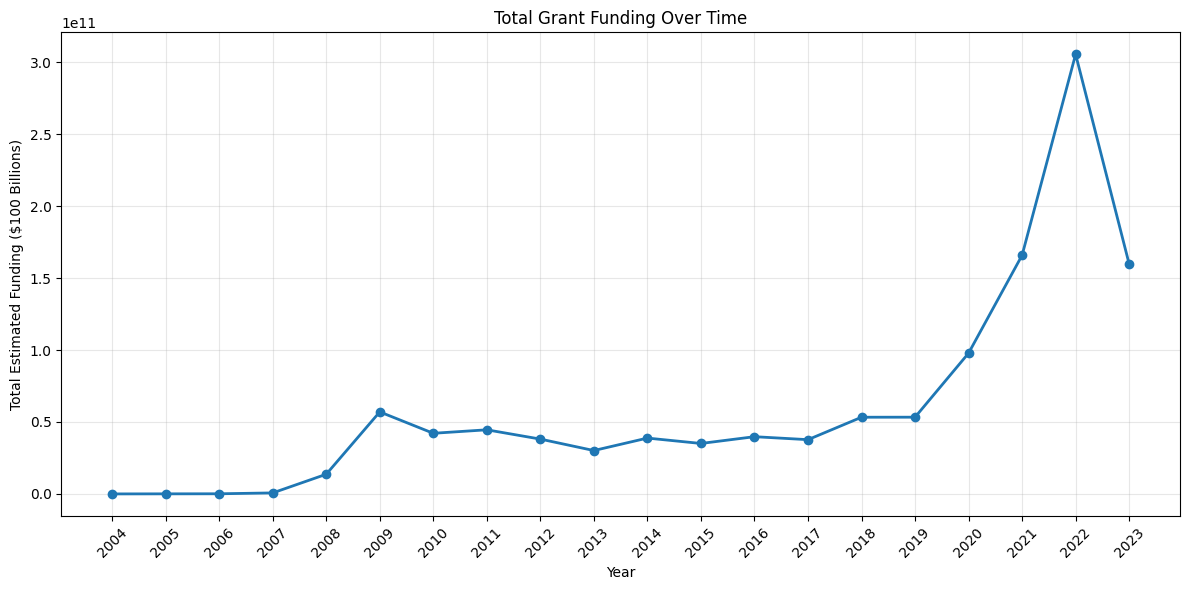

In [12]:
# Calculate total funding by year
funding_by_year = grants.groupby('posted_year')['estimated_funding'].sum()

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot funding
ax.set_xlabel('Year')
ax.set_ylabel('Total Estimated Funding ($100 Billions)')
ax.plot(
    funding_by_year.index,
    funding_by_year.values,
    marker='o',
    linewidth=2,
    label='Funding'
)

ax.grid(True, alpha=0.3)

plt.title('Total Grant Funding Over Time')

# Set x-axis to show all years as integers
min_year = int(funding_by_year.index.min())
max_year = int(funding_by_year.index.max())
ax.set_xticks(range(min_year, max_year + 1))
plt.xticks(rotation=45)

fig.tight_layout()
plt.show()


**Analysis:** We see a large spike in 2022 of around 300 billion dollars of funding. After many slow steady years besides a small 2009 increase, 2019-2022 see a massive rise. 2023 then falls down to around 150 billion dollars. I wonder if this could be correlated to post-crisis eras (2008 financial crisis and covid in 2020).

(It is  important to note that the grants could have risen because of an increase in tracking them into this dataset)

###**2.3. What is causing this spike in estimated funding around 2022? (using larger Grants table)**

In [13]:
# Filter grants from 2021-2023
grants_2021_2023 = grants[(grants['posted_year'] >= 2021) & (grants['posted_year'] <= 2023)]

# Get top 3 by estimated funding
top_3_funding = grants_2021_2023.nlargest(3, 'estimated_funding')

# Select only the columns you want to see
result = top_3_funding[['opportunity_title', 'agency_name', 'estimated_funding', 'posted_year', 'expected_number_of_awards']]

# Display the table
result

,opportunity_title,agency_name,estimated_funding,posted_year,expected_number_of_awards
7809,UNITED STATES DEPARTMENT OF AGRICULTURE FOOD F...,Food for Progress 10.606,1.780000e+11,2022,7.0
11089,Office of Postsecondary Education (OPE): Highe...,Department of Education,3.960000e+10,2021,NaN
11090,Office of Postsecondary Education (OPE): Highe...,Department of Education,3.960000e+10,2021,NaN


**Analysis:** The highest estimated funding by grants in this era where we saw a huge peak is the Food for Progress initiative, which invests in partner countries and expands US agricultural trade. The Department of Education's Higher Education Relief Fund represents a short-term but unprecedented surge in federal higher-education funding driven by the COVID-19 emergency.

###**3. EDA exploring agencies affiliated with grants, over time**

###**3.1. How are number of grants distributed by agency over time? (using larger Grants table)**

<Figure size 1400x600 with 0 Axes>

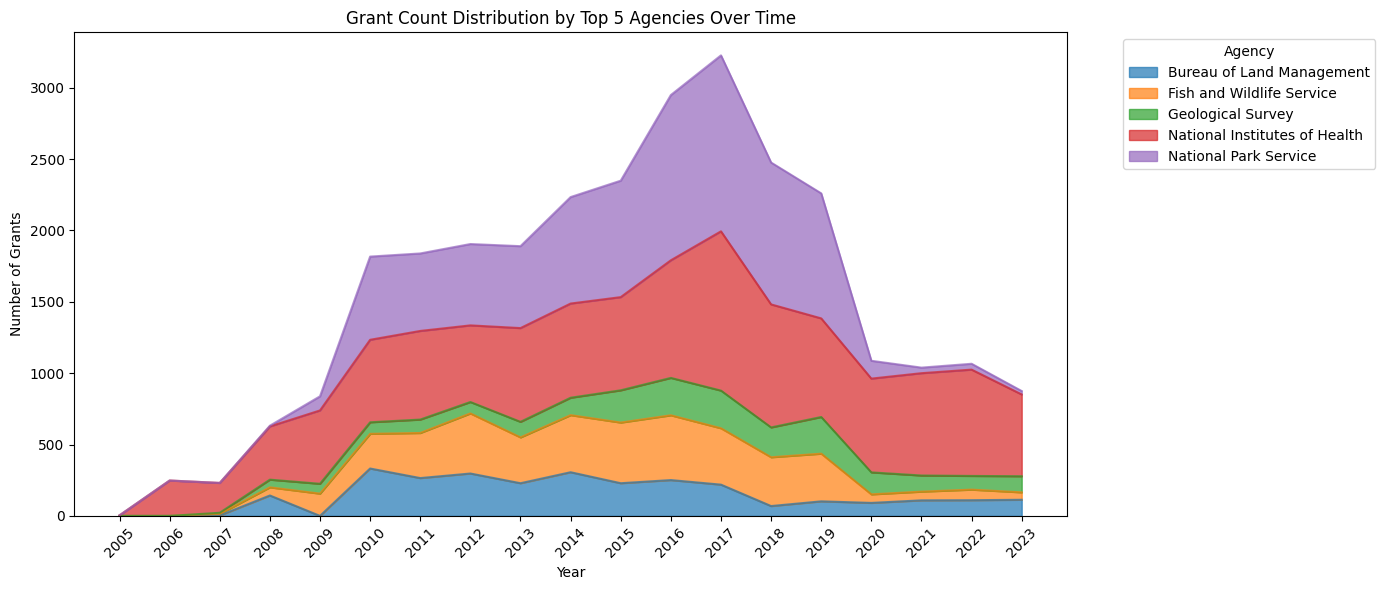

In [14]:
# Get top 5 agencies
top_5_agencies = grants['agency_name'].value_counts().head(5).index

# Filter to only top 5 agencies
grants_top5 = grants[grants['agency_name'].isin(top_5_agencies)]

# Count grants by year and agency
agency_by_year = grants_top5.groupby(['posted_year', 'agency_name']).size().unstack(fill_value=0)

# Stacked area chart
plt.figure(figsize=(14, 6))
agency_by_year.plot(kind='area', stacked=True, alpha=0.7, figsize=(14, 6))
plt.xlabel('Year')
plt.ylabel('Number of Grants')
plt.title('Grant Count Distribution by Top 5 Agencies Over Time')
plt.legend(title='Agency', bbox_to_anchor=(1.05, 1), loc='upper left')

# Fix x-axis to show integer years
plt.xticks(agency_by_year.index, rotation=45)

plt.tight_layout()
plt.show()

**Analysis:** This is a stacked area chart, so the thickness of each agency's band represents its contribution to the total number of grants (y-axis).

Analysis of these top 5 agencies by grant count:

* **Bureau of Land Management** has contributed around 100-300 grants per year, usually hovering around 200.
* **Fish and Wildlife Service** has contributed around 200-500 grants per year, declining significantly since 2020.
* **Geological Survey** has contributed around 100-300 grants per year, remaining relatively stable.
* **National Institutes of Health** has maintained a hefty and steady contribution of around 500-1000 grants per year, peaking around 2016-2017.
* **National Park Service** contributed 500-1200 grants per year from 2010 to 2017, peaking in 2017 at around 1200 grants. However, they have since declined dramatically, dropping to around 100-200 grants per year by 2020-2023.

###**3.2. How are number of grants distributed by agency over time? (using Merged table)**

<Figure size 1400x600 with 0 Axes>

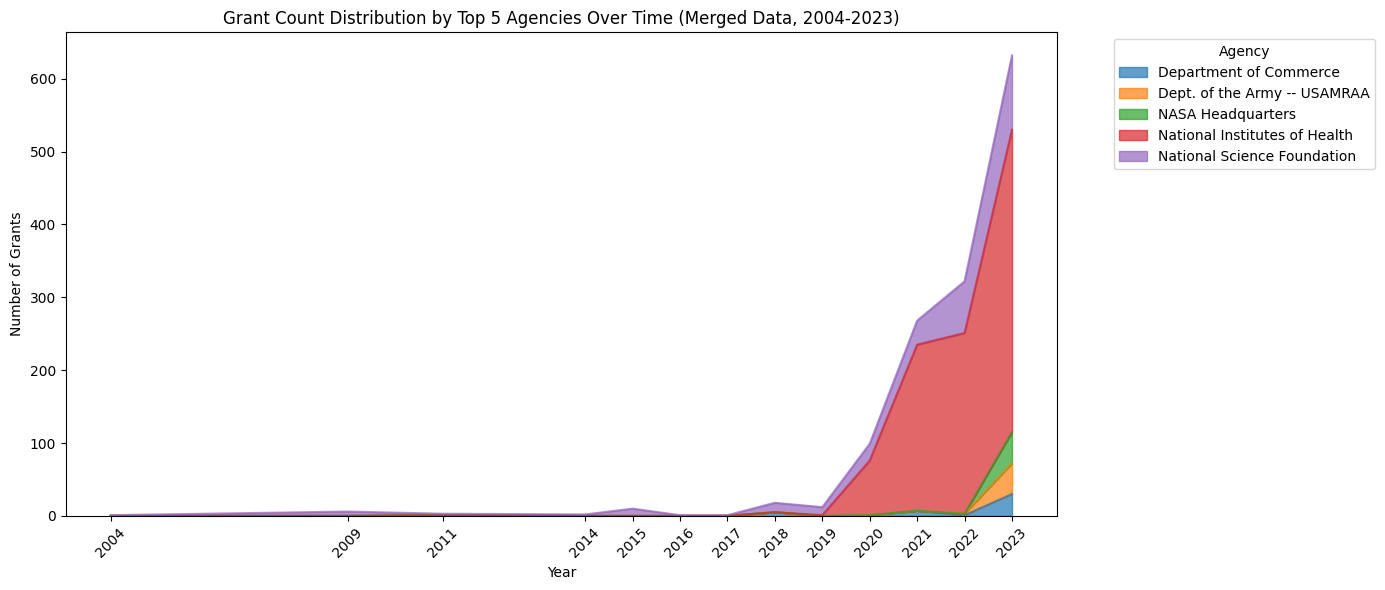

In [15]:
# Get top 5 agencies from merged data
top_5_agencies = merged['agency_name_y'].value_counts().head(5).index

# Filter to only top 5 agencies
merged_top5 = merged[merged['agency_name_y'].isin(top_5_agencies)]

# Count grants by year and agency
agency_by_year = merged_top5.groupby(['posted_year', 'agency_name_y']).size().unstack(fill_value=0)

# Stacked area chart
plt.figure(figsize=(14, 6))
agency_by_year.plot(kind='area', stacked=True, alpha=0.7, figsize=(14, 6))
plt.xlabel('Year')
plt.ylabel('Number of Grants')
plt.title('Grant Count Distribution by Top 5 Agencies Over Time (Merged Data, 2004-2023)')
plt.legend(title='Agency', bbox_to_anchor=(1.05, 1), loc='upper left')

# Fix x-axis to show integer years
plt.xticks(agency_by_year.index, rotation=45)

plt.tight_layout()
plt.show()

**Analysis:** It seems as though the Details (therefore, merged) table includes a different distribution of agencies, but has some similarities to the Grants table.
Analysis of these top 5 agencies by grant count:

* **National Institutes of Health** was also a top 5 agency in larger Grants table, and contributes by far the largest count of grants here.
* **Department of Commerce** saw an uptick from 2022 to 2023.
* **Dept of the Army** saw an uptick from 2022 to 2023.
* **NASA Headquarters** saw an uptick from 2022 to 2023.
* **National Science Foundation** relatively steady contribution from 2004 to 2023, but more substantial since around 2017.

Note that these upticks are likely largely influenced by an increase in tracking into this Details table.

###**3.3. How are value of grants distributed by agency over time? (using larger Grants table)**

<Figure size 1400x600 with 0 Axes>

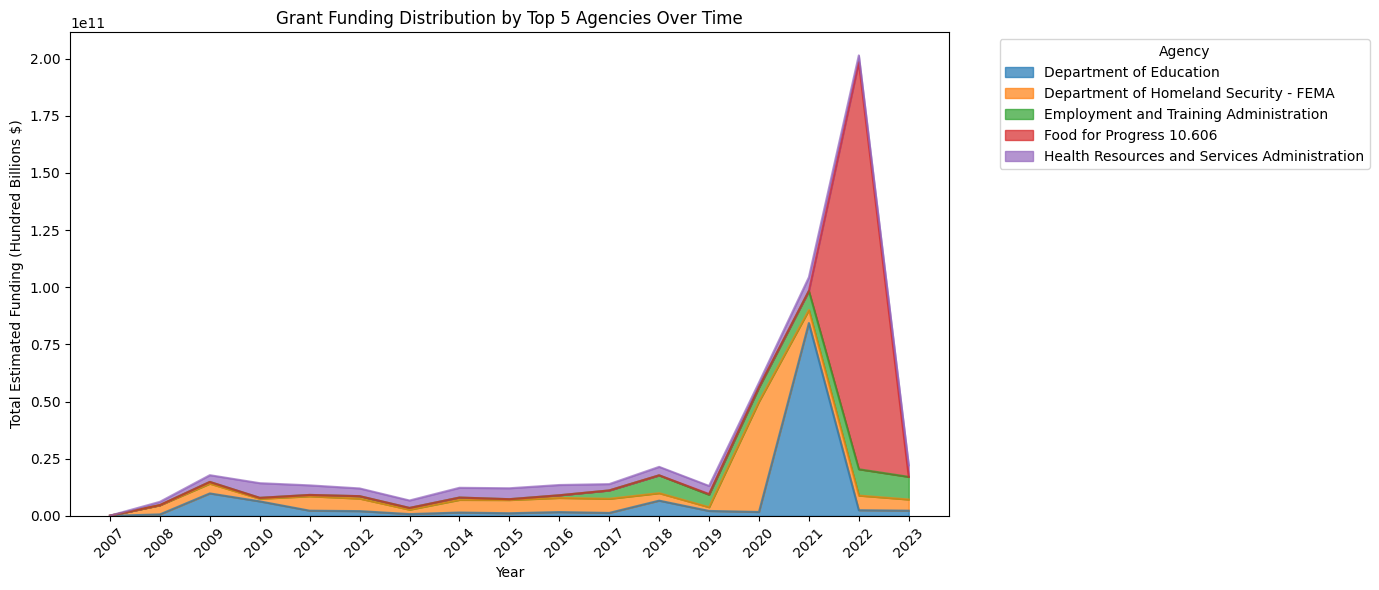

In [16]:
# Get top 5 agencies by total funding
top_5_agencies_funding = grants.groupby('agency_name')['estimated_funding'].sum().nlargest(5).index

# Filter to only top 5 agencies
grants_top5_funding = grants[grants['agency_name'].isin(top_5_agencies_funding)]

# Sum funding by year and agency
agency_funding_by_year = grants_top5_funding.groupby(['posted_year', 'agency_name'])['estimated_funding'].sum().unstack(fill_value=0)

# Stacked area chart
plt.figure(figsize=(14, 6))
agency_funding_by_year.plot(kind='area', stacked=True, alpha=0.7, figsize=(14, 6))
plt.xlabel('Year')
plt.ylabel('Total Estimated Funding (Hundred Billions $)')
plt.title('Grant Funding Distribution by Top 5 Agencies Over Time')
plt.legend(title='Agency', bbox_to_anchor=(1.05, 1), loc='upper left')

# Fix x-axis to show integer years
plt.xticks(agency_funding_by_year.index, rotation=45)

plt.tight_layout()
plt.show()

**Analysis:** This stacked area chart shows the total funding value distributed by the top 5 agencies over time, measured in hundreds of billions of dollars.

* **Department of Education** is stable at under \$20 billion annually until spiking to \$80 billion in 2021, then dropping back down by 2022.
* **Department of Homeland Security - FEMA** sees low funding until a surge around 2019-2021.
* **Employment and Training Administration** is relatively steady activity since 2016.
* **Food for Progress 10.606** is virtually absent until 2020, then became the largest contributor at over \$100 billion in 2021-2022 before declining.
* **Health Resources and Services Administration** was the most consistent agency, maintaining steady \$10-20 billion throughout the entire period.

The 2021-2022 period shows an extraordinary funding spike to \$200 billion total, likely due to COVID-19 relief programs, before returning to typical levels around \$20 billion by 2023.

###**3.4. How are value of grants distributed by agency over time? (using Merged table)**

<Figure size 1400x600 with 0 Axes>

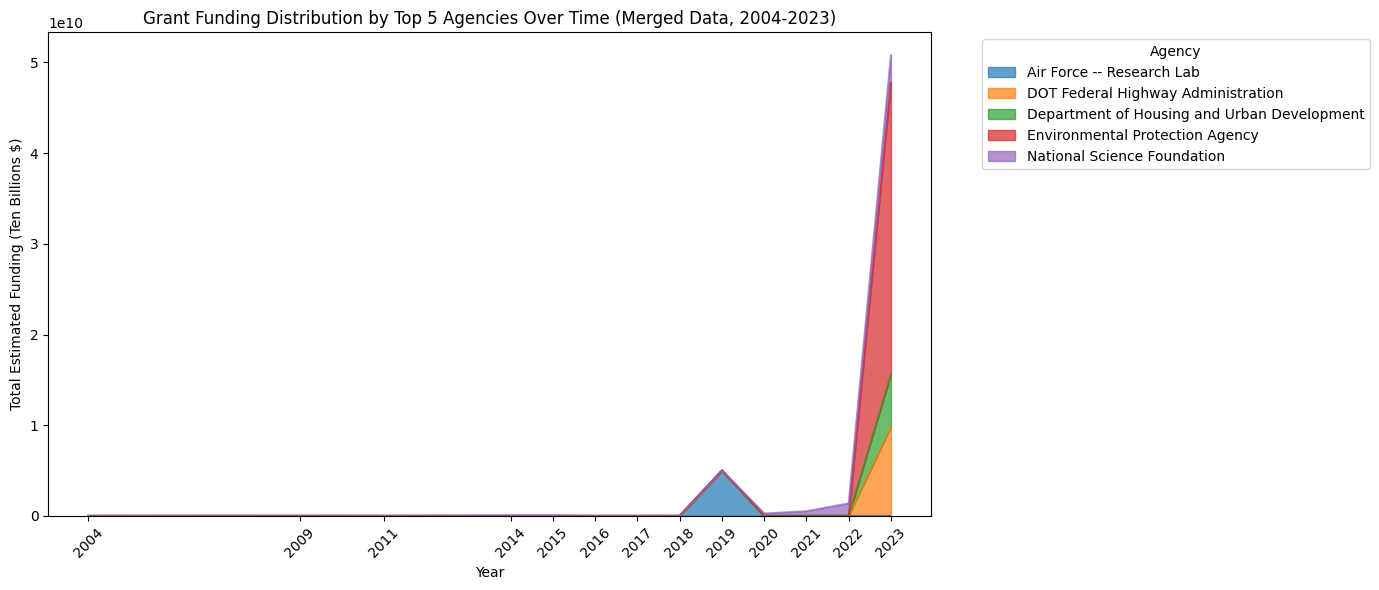

In [17]:
# Get top 5 agencies by total funding from merged data
top_5_agencies_funding = merged.groupby('agency_name_y')['estimated_total_program_funding'].sum().nlargest(5).index

# Filter to only top 5 agencies
merged_top5_funding = merged[merged['agency_name_y'].isin(top_5_agencies_funding)]

# Sum funding by year and agency
agency_funding_by_year = merged_top5_funding.groupby(['posted_year', 'agency_name_y'])['estimated_total_program_funding'].sum().unstack(fill_value=0)

# Stacked area chart
plt.figure(figsize=(14, 6))
agency_funding_by_year.plot(kind='area', stacked=True, alpha=0.7, figsize=(14, 6))
plt.xlabel('Year')
plt.ylabel('Total Estimated Funding (Ten Billions $)')
plt.title('Grant Funding Distribution by Top 5 Agencies Over Time (Merged Data, 2004-2023)')
plt.legend(title='Agency', bbox_to_anchor=(1.05, 1), loc='upper left')

# Fix x-axis to show integer years
plt.xticks(agency_funding_by_year.index, rotation=45)

plt.tight_layout()
plt.show()

**Analysis:** This stacked area chart shows the total funding value distributed by the top 5 agencies over time (using the merged table), measured in tens of billions of dollars.

* **Air Force- Research lab** sees its peak in 2019 at under \$10 billion.
* **DOT Federal Highway Administration** becomes apparent as it increases from 2022-2023.
* **Department of Housing and Urban Development** becomes apparent as it increases from 2022-2023.
* **Environmental Protection Agency** is the most noticable contributor to this graph with estimated funding reaching over \$20 billion from 2022 to 2023.
* **National Science Foundation** was the most consistent agency, maintaining a small but steady contribution since 2004.

As these are different than the top 5 agencies by funding in the larger Grants table, we will next dive into the intricacies of the Details/Merged tables.

###**4. EDA exploring potential "eras" of grants (with Details/Merged tables)**

###**4.1 What is the distribution of eligibility in grants? (using Merged table)**

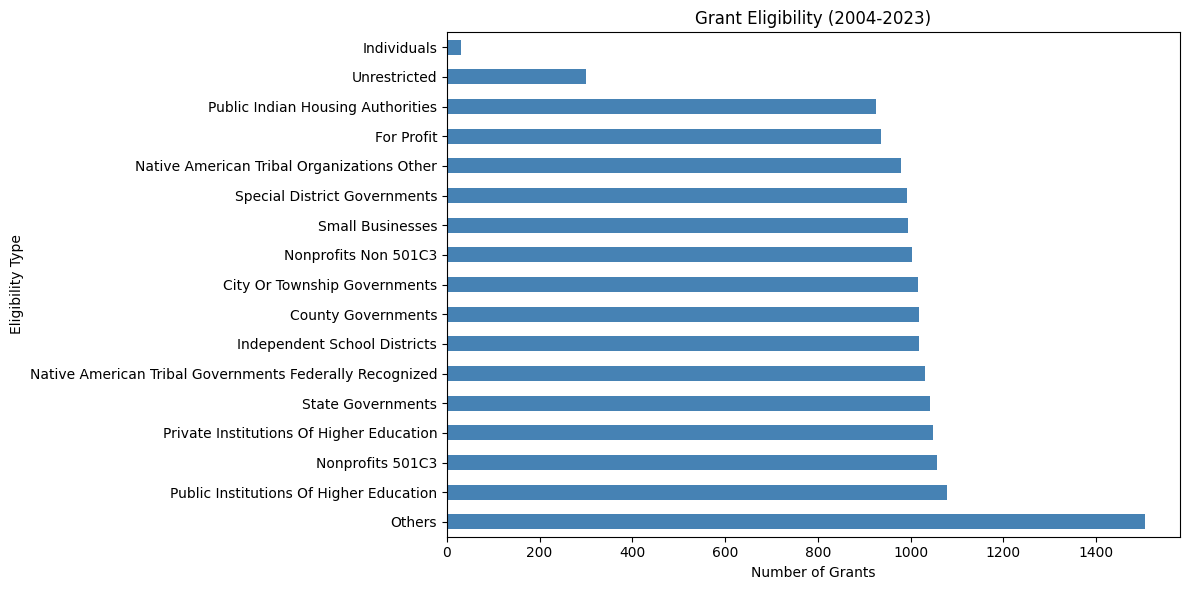

In [18]:
# Get all eligibility columns
eligibility_cols = [col for col in merged.columns if col.startswith('eligibility_')]

# Count how many grants have each eligibility type (True values)
eligibility_counts = merged[eligibility_cols].sum().sort_values(ascending=False)

# Clean up column names for display
eligibility_counts.index = eligibility_counts.index.str.replace('eligibility_', '').str.replace('_', ' ').str.title()

# Create bar chart
plt.figure(figsize=(12, 6))
eligibility_counts.plot(kind='barh', color='steelblue')
plt.xlabel('Number of Grants')
plt.ylabel('Eligibility Type')
plt.title('Grant Eligibility (2004-2023)')
plt.tight_layout()
plt.show()

**Analysis:** While "Others" is the most popular grant eligibility, most others are equally represented, except for unrestricted and individuals.

###**4.2 What is the distribution of category in grants? (using Merged table)**

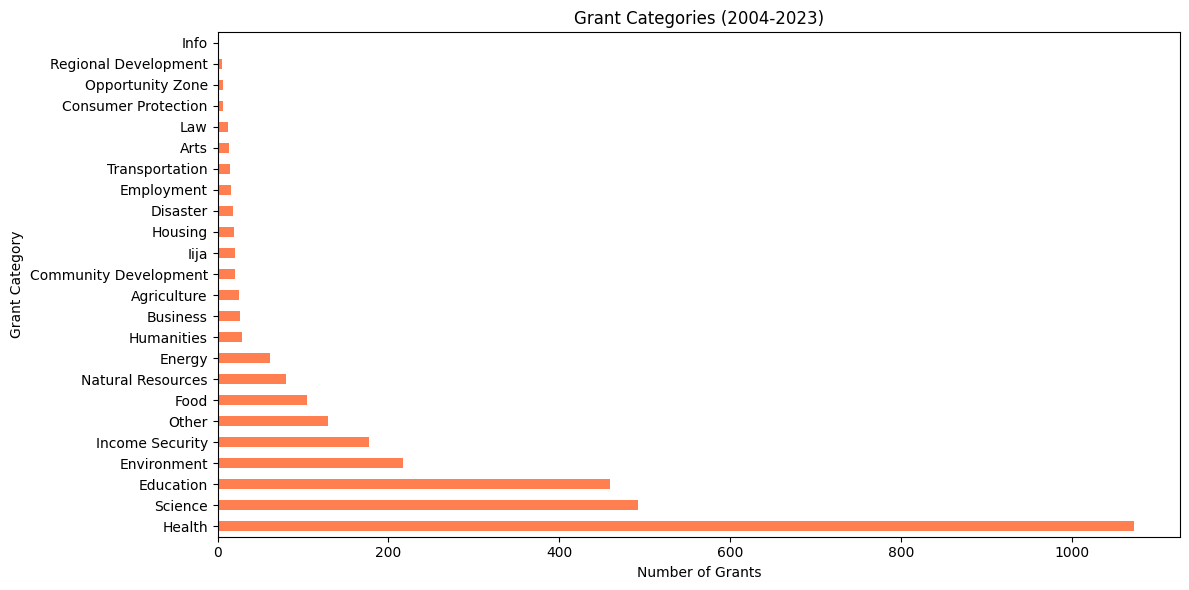


Top 5 Grant Categories:
Health             1073
Science             492
Education           460
Environment         217
Income Security     177
dtype: int64


In [19]:
# Get all category columns
category_cols = [col for col in merged.columns if col.startswith('category_')]

# Only keep columns that are actually boolean (exclude category_explanation which is object/string)
category_bool_cols = [col for col in category_cols if merged[col].dtype == 'bool']

# Count how many grants are in each category (True values)
category_counts = merged[category_bool_cols].sum().sort_values(ascending=False)

# Clean up column names for display
category_counts.index = category_counts.index.str.replace('category_', '').str.replace('_', ' ').str.title()

# Create bar chart
plt.figure(figsize=(12, 6))
category_counts.plot(kind='barh', color='coral')
plt.xlabel('Number of Grants')
plt.ylabel('Grant Category')
plt.title('Grant Categories (2004-2023)')
plt.tight_layout()
plt.show()

# Print top 5
print("\nTop 5 Grant Categories:")
print(category_counts.head())

**Analysis:** Health has- by far- the most number of grants represented in the Merged (and therefore, Details) table- at over 1000. After that comes Science and Education.

###**4.3. What are the trends in grant categories over time? (using Details table)**

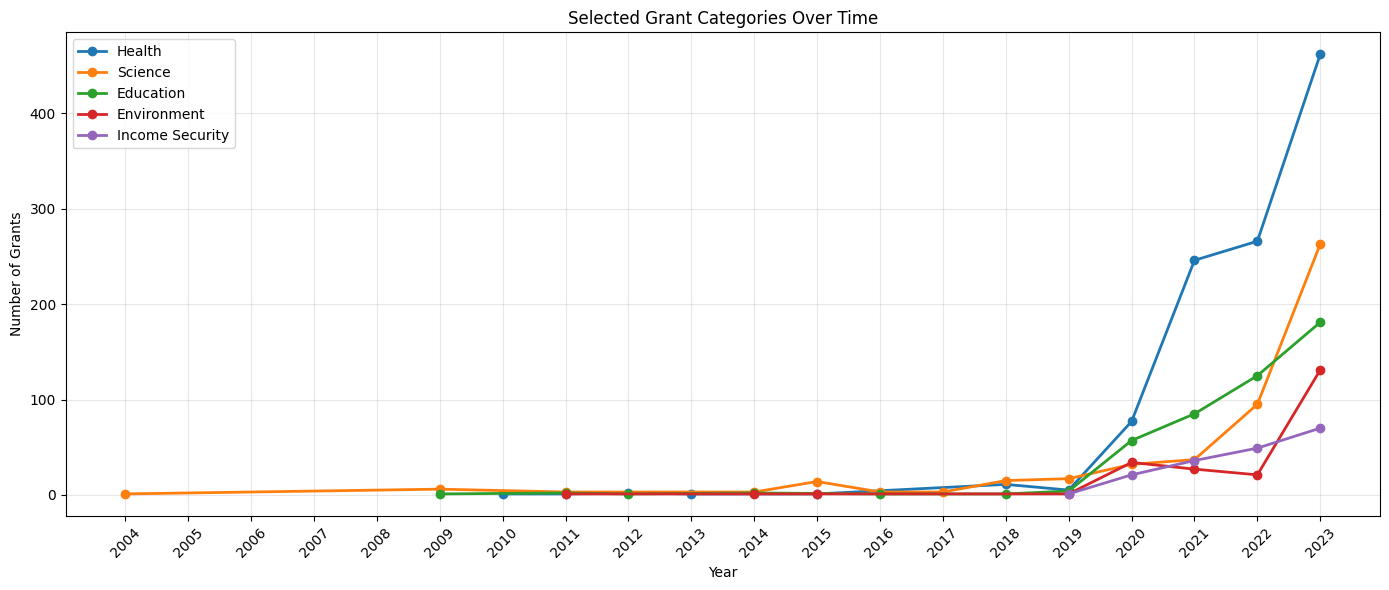

In [20]:
# Extract year
details['year'] = pd.to_datetime(details['posted_date'], errors='coerce').dt.year

# Categories to analyze
categories = {
    'Health': 'category_health',
    'Science': 'category_science',
    'Education': 'category_education',
    'Environment': 'category_environment',
    'Income Security': 'category_income_security'
}

# Count grants by year for each category
category_counts = {}
for label, col in categories.items():
    category_counts[label] = (
        details[details[col] == True]['year']
        .value_counts()
        .sort_index()
    )

# Plot
plt.figure(figsize=(14, 6))

for label, counts in category_counts.items():
    plt.plot(
        counts.index,
        counts.values,
        marker='o',
        linewidth=2,
        label=label
    )

plt.xlabel('Year')
plt.ylabel('Number of Grants')
plt.title('Selected Grant Categories Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

# Fix x-axis to show only whole years
plt.xticks(range(int(details['year'].min()), int(details['year'].max()) + 1, 1), rotation=45)

plt.tight_layout()
plt.show()

**Analysis:** Harnessing the Details table, I looked at different categories of grants to see trends in policy priorities/crisis responses. Science began the earliest (2004) and saw a jump in 2015, along with a steady increase post-around 2019 and a massive increase post-2022. The other grants also rose post-around 2019, with health being the largest in terms of count of grants- hitting around or over 450.

Note that this is impacted by what grants were tracked into the Details table.

## **Unsupervised Machine Learning M2 Phase**

### **1. Preparing Data for Clustering**


### **1.1. Selecting Features for Clustering**


In [21]:
# Checking on posted_date_x vs posted_year
merged[['posted_date_x', 'posted_year']]

,posted_date_x,posted_year
0,2023-09-28,2023
1,2023-09-28,2023
2,2023-09-28,2023
3,2023-09-28,2023
4,2023-09-28,2023
...,...,...
1995,2008-07-22,2008
1996,2008-06-17,2008
1997,2007-11-28,2007
1998,2007-11-28,2007


Features that will be used in unsupervised machine learning to see if time-bound "eras" are visible:


*   agency_name_x
*   estimated_funding
*   posted_year
*   eligibility (boolean that are turned into 0s/1s for ML)
*   category (boolean that are turned into 0s/1s for ML)

### **1.2. Data Cleaning- Handling Missing Values, Converting Datatypes**


In [22]:
# Get eligibility columns (all boolean)
eligibility_cols = [col for col in merged.columns if col.startswith('eligibility_')]

# Get category columns (only boolean, not category_explanation)
category_cols = [col for col in merged.columns if col.startswith('category_') and merged[col].dtype == 'bool']

# Create list of all features we want
features_to_keep = ['agency_name_x', 'estimated_funding', 'posted_year'] + eligibility_cols + category_cols

# Create new ML dataframe with only these features
merged_ml = merged[features_to_keep].copy()

# Ensure correct datatypes
merged_ml['agency_name_x'] = merged_ml['agency_name_x'].astype(str)  # Categorical (will encode later)
merged_ml['estimated_funding'] = merged_ml['estimated_funding'].astype(float)  # Numeric
merged_ml['posted_year'] = merged_ml['posted_year'].astype(int)  # Numeric

# Boolean columns (eligibility and category) are already bool, but convert to int (0/1) for clustering
for col in eligibility_cols + category_cols:
    merged_ml[col] = merged_ml[col].astype(int)  # Convert True/False to 1/0

print("Shape:", merged_ml.shape)
print("\nData types:")
print(merged_ml.dtypes)

Shape: (2000, 44)

Data types:
agency_name_x                                                           object
estimated_funding                                                      float64
posted_year                                                              int64
eligibility_individuals                                                  int64
eligibility_state_governments                                            int64
eligibility_county_governments                                           int64
eligibility_independent_school_districts                                 int64
eligibility_city_or_township_governments                                 int64
eligibility_special_district_governments                                 int64
eligibility_native_american_tribal_governments_federally_recognized      int64
eligibility_native_american_tribal_organizations_other                   int64
eligibility_nonprofits_501c3                                             int64
eligibility_nonprofit

In [23]:
# Check for missing values in merged_ml
print("Missing values in merged_ml:")
print(merged_ml.isnull().sum())

Missing values in merged_ml:
agency_name_x                                                             0
estimated_funding                                                      1315
posted_year                                                               0
eligibility_individuals                                                   0
eligibility_state_governments                                             0
eligibility_county_governments                                            0
eligibility_independent_school_districts                                  0
eligibility_city_or_township_governments                                  0
eligibility_special_district_governments                                  0
eligibility_native_american_tribal_governments_federally_recognized       0
eligibility_native_american_tribal_organizations_other                    0
eligibility_nonprofits_501c3                                              0
eligibility_nonprofits_non_501c3                           

In [24]:
merged_ml_clean = merged_ml.dropna(subset=['estimated_funding'])
print("Rows after dropping NAs:", len(merged_ml_clean))

Rows after dropping NAs: 685


**Analysis and explanation:** Unfortunately, a significant number of estimated_funding rows were missing from this Merged table. Although dropping grants with missing estimated_funding reduced the dataset from 2,000 to 685 observations, retaining this feature is critical for identifying policy-era archetypes, as funding amounts reflect federal priorities and resource allocation strategies that define distinct grant-making periods, and imputing 66% of funding values would introduce artificial patterns that could mislead the clustering algorithm.

### **2. Preprocessing: Normalization**

In [25]:
# Checking for skewed estimated_funding (to see if it needs log transformation)
print("Estimated funding stats:")
print(merged_ml['estimated_funding'].describe())
print("\nTop 5 values:")
print(merged_ml['estimated_funding'].nlargest(5).values)

Estimated funding stats:
count    6.850000e+02
mean     1.295782e+08
std      8.234683e+08
min      0.000000e+00
25%      2.500000e+06
50%      8.800000e+06
75%      3.000000e+07
max      1.397000e+10
Name: estimated_funding, dtype: float64

Top 5 values:
[1.3970e+10 9.6201e+09 7.0000e+09 6.0000e+09 5.0000e+09]


**Analysis:** estimated_funding is largely skewed, so I will log transform it to compress extreme values.

###**2.1 Preprocessing/Normalization Attempt 1**

In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

# Step 1: Drop rows with missing estimated_funding
merged_ml_clean = merged_ml.dropna(subset=['estimated_funding'])

print("Rows after dropping NAs:", len(merged_ml_clean))
print("\nYear distribution:")
print(merged_ml_clean['posted_year'].value_counts().sort_index())

# Step 2: Log transform estimated_funding (because of those huge values!)
merged_ml_clean['estimated_funding'] = np.log1p(merged_ml_clean['estimated_funding'])

print("\nLog-transformed funding stats:")
print(merged_ml_clean['estimated_funding'].describe())

# Step 3: Separate numeric, categorical, and binary features
numeric_features = ['estimated_funding', 'posted_year']
categorical_features = ['agency_name_x']
binary_features = eligibility_cols + category_cols  # Already 0/1, no scaling needed

# Step 4: Create preprocessor with scaling and encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('bin', 'passthrough', binary_features)  # Keep binary as-is (already 0/1)
    ])

# Step 5: Fit and transform the data
merged_preprocessed = preprocessor.fit_transform(merged_ml_clean)

# Step 6: Get feature names for interpretation later
numeric_feature_names = numeric_features
encoder = preprocessor.named_transformers_['cat']
categorical_feature_names = encoder.get_feature_names_out(categorical_features)
binary_feature_names = binary_features

# Combine all feature names
all_feature_names = list(numeric_feature_names) + list(categorical_feature_names) + list(binary_feature_names)

# Step 7: Convert to DataFrame
merged_preprocessed_df = pd.DataFrame(merged_preprocessed, columns=all_feature_names)

print("\n" + "="*50)
print("PREPROCESSING COMPLETE")
print("="*50)
print("Preprocessed data shape:", merged_preprocessed.shape)
print("Total features:", len(all_feature_names))
print("\nFeature breakdown:")
print(f"- Numeric features (scaled): {len(numeric_features)}")
print(f"- Agency features (one-hot): {len(categorical_feature_names)}")
print(f"- Binary features (eligibility + category): {len(binary_features)}")

Rows after dropping NAs: 685

Year distribution:
posted_year
2007      2
2008      2
2009      7
2010      4
2011      6
2012      4
2013      2
2014      5
2015      9
2016      3
2017      3
2018     11
2019     12
2020     28
2021     55
2022    105
2023    427
Name: count, dtype: int64

Log-transformed funding stats:
count    685.000000
mean      15.443753
std        3.767686
min        0.000000
25%       14.731802
50%       15.990262
75%       17.216708
max       23.360178
Name: estimated_funding, dtype: float64

PREPROCESSING COMPLETE
Preprocessed data shape: (685, 150)
Total features: 150

Feature breakdown:
- Numeric features (scaled): 2
- Agency features (one-hot): 107
- Binary features (eligibility + category): 41


/tmp/ipython-input-2109084115.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_ml_clean['estimated_funding'] = np.log1p(merged_ml_clean['estimated_funding'])


*   StandardScaler (on numeric values) centers data on mean=0 and std=1. This prevents large values, like funding amounts, from dominating.
*   OneHotEncoder (on categorical) creates binary columns for each agency

Now, there are 150 features to be clustered with (many of them one hot 0/1s).

**Analysis:** Right now, agency differences contribute 107 dimensions to distance calculation. Everything else contributes 43 dimensions. Because there are so many agency features (now one-hot encoded), this poses a potential concern in terms of clusters being heavily influenced by the dominant signal "agency." I don't want to get clusters like "Cluster 1 = all NIH grants" regardless of year/category. Therefore, I am going to limit the "agencies" feature to top 10 agencies + other.


###**2.2 Preprocessing/Normalization Attempt 2- Top 10 Agencies + Other (by count)**

In [27]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

# Step 1: Drop rows with missing estimated_funding (same as before)
merged_ml_clean_simplified = merged_ml.dropna(subset=['estimated_funding'])

print("Rows after dropping NAs:", len(merged_ml_clean_simplified))

# Step 2: Create agency_simplified (Top 10 + Other)
top_10_agencies = merged_ml_clean_simplified['agency_name_x'].value_counts().head(10).index

merged_ml_clean_simplified['agency_simplified'] = merged_ml_clean_simplified['agency_name_x'].apply(
    lambda x: x if x in top_10_agencies else 'Other'
)

print("\nAgency simplification:")
print("Original unique agencies:", merged_ml_clean_simplified['agency_name_x'].nunique())
print("Simplified to:", merged_ml_clean_simplified['agency_simplified'].nunique())
print("\nSimplified agency distribution:")
print(merged_ml_clean_simplified['agency_simplified'].value_counts())

# Step 3: Log transform estimated_funding
merged_ml_clean_simplified['estimated_funding'] = np.log1p(merged_ml_clean_simplified['estimated_funding'])

# Step 4: Separate numeric, categorical, and binary features
numeric_features = ['estimated_funding', 'posted_year']
categorical_features = ['agency_simplified']  # Using simplified version!
binary_features = eligibility_cols + category_cols

# Step 5: Create preprocessor with scaling and encoding
preprocessor_simplified = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('bin', 'passthrough', binary_features)
    ])

# Step 6: Fit and transform the data
merged_preprocessed_simplified = preprocessor_simplified.fit_transform(merged_ml_clean_simplified)

# Step 7: Get feature names
numeric_feature_names = numeric_features
encoder_simplified = preprocessor_simplified.named_transformers_['cat']
categorical_feature_names = encoder_simplified.get_feature_names_out(categorical_features)
binary_feature_names = binary_features

all_feature_names_simplified = list(numeric_feature_names) + list(categorical_feature_names) + list(binary_feature_names)

print("\n" + "="*50)
print("SIMPLIFIED PREPROCESSING COMPLETE")
print("="*50)
print("Preprocessed data shape:", merged_preprocessed_simplified.shape)
print("Total features:", len(all_feature_names_simplified))
print("\nFeature breakdown:")
print(f"- Numeric features (scaled): {len(numeric_features)}")
print(f"- Agency features (one-hot): {len(categorical_feature_names)}")
print(f"- Binary features (eligibility + category): {len(binary_features)}")

Rows after dropping NAs: 685

Agency simplification:
Original unique agencies: 107
Simplified to: 11

Simplified agency distribution:
agency_simplified
Other                                               232
National Science Foundation                         223
Dept. of the Army -- USAMRAA                         42
Environmental Protection Agency                      40
Fish and Wildlife Service                            27
Centers for Disease Control and Prevention - ERA     25
Department of Commerce                               25
National Energy Technology Laboratory                22
Golden Field Office                                  17
Department of Housing and Urban Development          17
National Endowment for the Humanities                15
Name: count, dtype: int64

SIMPLIFIED PREPROCESSING COMPLETE
Preprocessed data shape: (685, 54)
Total features: 54

Feature breakdown:
- Numeric features (scaled): 2
- Agency features (one-hot): 11
- Binary features (eligibility + c

/tmp/ipython-input-1037278137.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_ml_clean_simplified['agency_simplified'] = merged_ml_clean_simplified['agency_name_x'].apply(
/tmp/ipython-input-1037278137.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_ml_clean_simplified['estimated_funding'] = np.log1p(merged_ml_clean_simplified['estimated_funding'])


**Analysis:** Now, hopefully other features will get a fair shot alongside agencies in clustering. The table name I will use for clustering is "merged_preprocessed_simplified."

### **3. Anomaly Detection**

In [28]:
print(merged_ml_clean_simplified['estimated_funding'].describe())
print(merged_ml_clean_simplified['posted_year'].min(), "-", merged_ml_clean_simplified['posted_year'].max())

count    685.000000
mean      15.443753
std        3.767686
min        0.000000
25%       14.731802
50%       15.990262
75%       17.216708
max       23.360178
Name: estimated_funding, dtype: float64
2007 - 2023


**Analysis:** looks okay, as estimated funding amounts were log-transformed to reduce right skew and then standardized prior to anomaly detection. This ensured that extreme funding values did not dominate distance-based methods.

### **4. Determining Optimal Number of Clusters**


### **4.1. Elbow method**

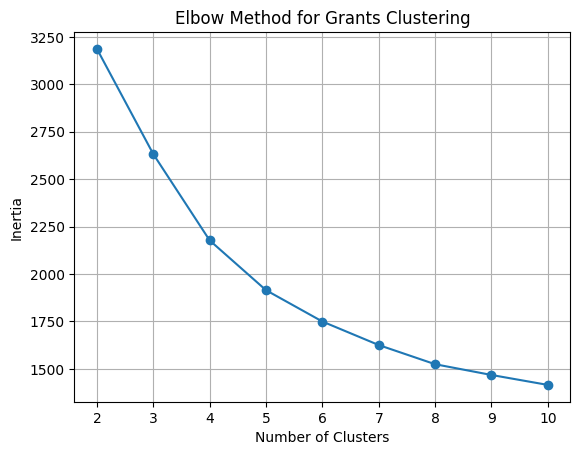

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(merged_preprocessed_simplified)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow Method for Grants Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

**Analysis:** There is not a clear "elbow" that I am seeing (at which increasing k doesn't decrease inertia as much as before), but it may be 4. I will try k=4, or 4 clusters. I will also test out k=5, as it could be a slight elbow.

### **4.2. Silhouette score**

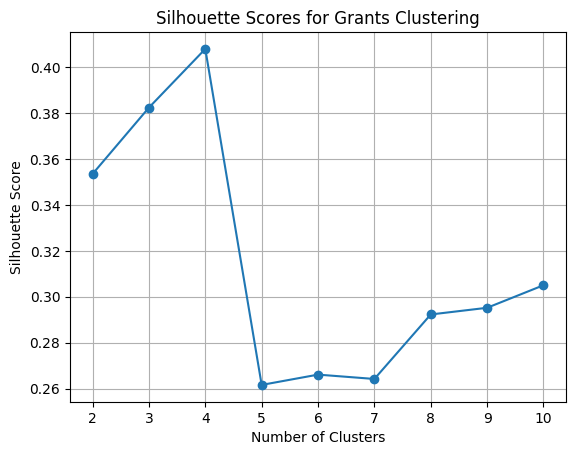

In [30]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(merged_preprocessed_simplified)
    scores.append(silhouette_score(merged_preprocessed_simplified, labels))

plt.plot(range(2, 11), scores, marker='o')
plt.title("Silhouette Scores for Grants Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

**Analysis:** Silhouette scores mean the normalized difference between cluster cohesion and cluster separation. Closer to 1 means that clusters are tight and well separated. Closer to -1 means that they are sprawling or overlapped.

My silhouette graph shows that k=4 produces the best silhouette score of over 0.40. I will try k=4. I will also try k=3, because it seems to be the next best option with a score around 0.38.

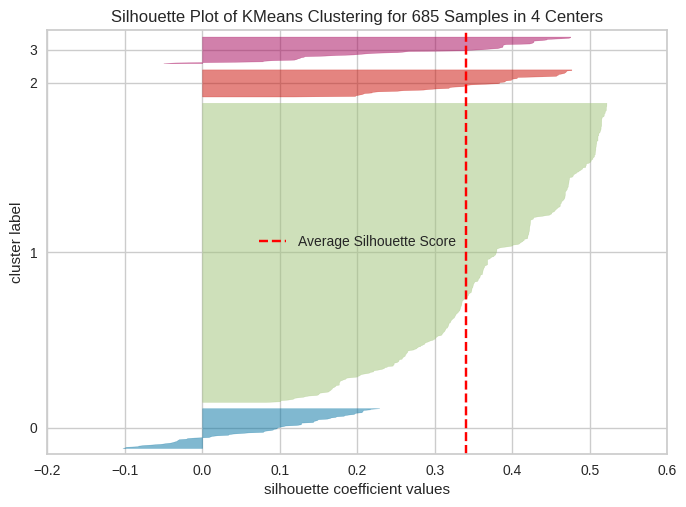

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 685 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [38]:
from yellowbrick.cluster import SilhouetteVisualizer

# Create silhouette visualizer for k=4
kmeans_model = KMeans(n_clusters=4, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, colors='yellowbrick')

visualizer.fit(merged_preprocessed_simplified)
visualizer.show()

**Analysis:** The silhouette plot reveals that Cluster 1 (green, 506 grants) is well-defined and cohesive with most points above the average score, Clusters 2 and 3 (pink and salmon) show moderate clustering quality, while Cluster 0 (blue, 40 grants) is the smallest and weakest with many points having low silhouette coefficients, suggesting it may be a transitional or less distinct policy era compared to the other three clusters.

### **5. Run Clustering with K-Means, and Preliminary Analysis**

I have decided to use K-means to perform clustering, as my dataset has high dimensionality (54 features). I want distinct "policy-era archetypes" and K-means tries to give clean, non-overlapping groups. This will be nice to interpret to see if "eras" emerge. Hierarcical would be best if I wanted to see nested relationships (sub-eras within eras), or a dendrogram.

### **5.1. Run Clustering with K-Means- k=4**

k=4 seems to be our best bet from silhouette score, so I will try first.

In [31]:
from sklearn.cluster import KMeans

# Fit K-Means with k=4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_4.fit(merged_preprocessed_simplified)
labels_4 = kmeans_4.labels_

# Add cluster labels back to the clean dataframe
merged_ml_clean_simplified['cluster_4'] = labels_4

print("Cluster distribution:")
print(merged_ml_clean_simplified['cluster_4'].value_counts().sort_index())
print()

Cluster distribution:
cluster_4
0     40
1    506
2    111
3     28
Name: count, dtype: int64



/tmp/ipython-input-4254686140.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_ml_clean_simplified['cluster_4'] = labels_4


###**Preliminary Analysis of k=4**

In [32]:
print("TEMPORAL PATTERNS BY CLUSTER")
print(merged_ml_clean_simplified.groupby('cluster_4')['posted_year'].agg(['min', 'max', 'mean', 'median', 'count']))
print()

print("FEATURE AVERAGES BY CLUSTER")
print(merged_ml_clean_simplified.groupby('cluster_4')[['estimated_funding', 'posted_year']].mean())
print()

print("TOP 3 AGENCIES PER CLUSTER")
for cluster in [0, 1, 2, 3]:
    print()
    print("Cluster", cluster)
    cluster_data = merged_ml_clean_simplified[merged_ml_clean_simplified['cluster_4'] == cluster]
    print(cluster_data['agency_simplified'].value_counts().head(3))

print()
print("TOP 3 CATEGORIES PER CLUSTER")
for cluster in [0, 1, 2, 3]:
    print()
    print("Cluster", cluster)
    cluster_data = merged_ml_clean_simplified[merged_ml_clean_simplified['cluster_4'] == cluster]
    category_sums = cluster_data[category_cols].sum().sort_values(ascending=False)
    print(category_sums.head(3))

TEMPORAL PATTERNS BY CLUSTER
            min   max         mean  median  count
cluster_4                                        
0          2007  2017  2011.925000  2011.5     40
1          2018  2023  2022.341897  2023.0    506
2          2018  2023  2022.423423  2023.0    111
3          2009  2023  2020.642857  2023.0     28

FEATURE AVERAGES BY CLUSTER
           estimated_funding  posted_year
cluster_4                                
0                  16.323886  2011.925000
1                  16.039763  2022.341897
2                  16.305363  2022.423423
3                   0.000000  2020.642857

TOP 3 AGENCIES PER CLUSTER

Cluster 0
agency_simplified
Other                          28
National Science Foundation    11
Department of Commerce          1
Name: count, dtype: int64

Cluster 1
agency_simplified
National Science Foundation     211
Other                           140
Dept. of the Army -- USAMRAA     42
Name: count, dtype: int64

Cluster 2
agency_simplified
Other        

**Analysis:** 4 policy-era architypes were found:


**Cluster 0 (40 grants): early mixed science era (2007-2017).**
Diverse mix of agencies. Focus on science, general research, health. Pre-modern era, more fragmented agency landscape.

**Cluster 1 (506 grants): modern science dominance era (2018-2023).** Largest cluster, with a major focus on science, but also including environment and other. This is the mainstream modern era with a heavy emphasis on scientific research.

**Cluster 2 (111 grants): health and natural resources era (2018-2023).** The same period as cluster 1, but with a different focus. Here, agencies are CDC, Fish & Wildlife, and others. "Health" comprises 40 of these grants. This cluster shows public health/conservation priorities in the modern era.

**Cluster 3 (28 grants): energy transition era (2009-2023)**, with a peak around 2020). Dominated by energy grants and energy agencies. Strangely, the estimated funding shows $0. I will investigate. This cluster is a climate/energy policy push.

Unfortunately, it looks that in my data cleaning, grants from 2004 to 2007 were dropped likely because they did not include estimated_funding. Verifying that:


In [41]:
print("Posted year range:")
print("Min year:", merged_ml_clean['posted_year'].min())
print("Max year:", merged_ml_clean['posted_year'].max())

Posted year range:
Min year: 2007
Max year: 2023


Verifying that cluster 3 really had 0 estimated funding:

In [33]:
print("Cluster 3 funding check:")
print(merged_ml_clean_simplified[merged_ml_clean_simplified['cluster_4'] == 3]['estimated_funding'].describe())

Cluster 3 funding check:
count    28.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: estimated_funding, dtype: float64


**Analysis:** It seems that it is true, cluster 3 really had $0 funding. We suspect that this is because funding was not finalized/applicable at posting time. This is important to note because estimated_funding=0 does not necessarily mean that finalized funding=0. Zeros could be associated with grant type & maturity, not success/failure.

### **5.2. Run Clustering with K-Means- k=3**

To see if k=3 produces any more fruitful clusters, I tried it (next best silhouette score).

In [42]:
# Fit K-Means with k=3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3.fit(merged_preprocessed_simplified)
labels_3 = kmeans_3.labels_

# Add cluster labels back to the clean dataframe
merged_ml_clean_simplified['cluster_3'] = labels_3

print("Cluster distribution:")
print(merged_ml_clean_simplified['cluster_3'].value_counts().sort_index())
print()

Cluster distribution:
cluster_3
0    526
1    112
2     47
Name: count, dtype: int64



/tmp/ipython-input-4160595608.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_ml_clean_simplified['cluster_3'] = labels_3


###**Preliminary Analysis of k=3**

In [43]:
print("TEMPORAL PATTERNS BY CLUSTER")
print(merged_ml_clean_simplified.groupby('cluster_3')['posted_year'].agg(['min', 'max', 'mean', 'median', 'count']))
print()

print("FEATURE AVERAGES BY CLUSTER")
print(merged_ml_clean_simplified.groupby('cluster_3')[['estimated_funding', 'posted_year']].mean())
print()

print("TOP 3 AGENCIES PER CLUSTER")
for cluster in [0, 1, 2]:
    print()
    print("Cluster", cluster)
    cluster_data = merged_ml_clean_simplified[merged_ml_clean_simplified['cluster_3'] == cluster]
    print(cluster_data['agency_simplified'].value_counts().head(3))

print()
print("TOP 3 CATEGORIES PER CLUSTER")
for cluster in [0, 1, 2]:
    print()
    print("Cluster", cluster)
    cluster_data = merged_ml_clean_simplified[merged_ml_clean_simplified['cluster_3'] == cluster]
    category_sums = cluster_data[category_cols].sum().sort_values(ascending=False)
    print(category_sums.head(3))

TEMPORAL PATTERNS BY CLUSTER
            min   max         mean  median  count
cluster_3                                        
0          2018  2023  2022.357414  2023.0    526
1          2018  2023  2022.428571  2023.0    112
2          2007  2017  2012.276596  2012.0     47

FEATURE AVERAGES BY CLUSTER
           estimated_funding  posted_year
cluster_3                                
0                  15.429886  2022.357414
1                  16.159780  2022.428571
2                  13.892669  2012.276596

TOP 3 AGENCIES PER CLUSTER

Cluster 0
agency_simplified
National Science Foundation     211
Other                           145
Dept. of the Army -- USAMRAA     42
Name: count, dtype: int64

Cluster 1
agency_simplified
Other                                               54
Centers for Disease Control and Prevention - ERA    21
Fish and Wildlife Service                           11
Name: count, dtype: int64

Cluster 2
agency_simplified
Other                          33
National

**Analysis:** estimated_funding seems to have much less of an impact in this k=3 clustering (all clusters have similar estimated_funding averages), which is optimal since estimated_funding=0 could be noise, as discussed above.

For clustering when k=3, 3 archetypes emerged:

**Cluster 0 (526 grants): modern science & environment expansion era (2018–2023).**
This largest cluster represents contemporary federal grantmaking, dominated by the National Science Foundation. It emphasizes science, with strong representation from environmental and energy-related grants, reflecting modern large-scale investment in research and sustainability.

**Cluster 1 (112 grants): modern public health & natural resources era (2018–2023).**
Occurring in the same time period as Cluster 0, this cluster has a distinct policy focus. It is driven by agencies such as the CDC and Fish & Wildlife Service and concentrates on health and natural resources, highlighting public health and conservation priorities in the modern era.

**Cluster 2 (47 grants): pre-modern science baseline era (2007–2017).**
This smallest cluster represents an earlier phase of grantmaking with a more fragmented agency landscape. Science is the dominant category, with some health and general-purpose grants, serving as a baseline prior to the expansion of modern federal funding programs. We had less data in this time period, so this makes sense.

### **5.3. Run Clustering with K-Means- k=5**

k=5 was a potential elbow, so I will try it now.

In [44]:
# Fit K-Means with k=5
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_5.fit(merged_preprocessed_simplified)
labels_5 = kmeans_5.labels_

# Add cluster labels back to the clean dataframe
merged_ml_clean_simplified['cluster_5'] = labels_5

print("Cluster distribution:")
print(merged_ml_clean_simplified['cluster_5'].value_counts().sort_index())
print()

Cluster distribution:
cluster_5
0    263
1    106
2    248
3     40
4     28
Name: count, dtype: int64



/tmp/ipython-input-2899359130.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_ml_clean_simplified['cluster_5'] = labels_5


###**Preliminary Analysis of k=5**

In [45]:
print("TEMPORAL PATTERNS BY CLUSTER")
print(merged_ml_clean_simplified.groupby('cluster_5')['posted_year'].agg(['min', 'max', 'mean', 'median', 'count']))
print()

print("FEATURE AVERAGES BY CLUSTER")
print(merged_ml_clean_simplified.groupby('cluster_5')[['estimated_funding', 'posted_year']].mean())
print()

print("TOP 3 AGENCIES PER CLUSTER")
for cluster in [0, 1, 2, 3, 4]:
    print()
    print("Cluster", cluster)
    cluster_data = merged_ml_clean_simplified[merged_ml_clean_simplified['cluster_5'] == cluster]
    print(cluster_data['agency_simplified'].value_counts().head(3))

print()
print("TOP 3 CATEGORIES PER CLUSTER")
for cluster in [0, 1, 2, 3, 4]:
    print()
    print("Cluster", cluster)
    cluster_data = merged_ml_clean_simplified[merged_ml_clean_simplified['cluster_5'] == cluster]
    category_sums = cluster_data[category_cols].sum().sort_values(ascending=False)
    print(category_sums.head(3))

TEMPORAL PATTERNS BY CLUSTER
            min   max         mean  median  count
cluster_5                                        
0          2018  2023  2022.106464  2023.0    263
1          2018  2023  2022.396226  2023.0    106
2          2018  2023  2022.604839  2023.0    248
3          2007  2017  2011.925000  2011.5     40
4          2009  2023  2020.642857  2023.0     28

FEATURE AVERAGES BY CLUSTER
           estimated_funding  posted_year
cluster_5                                
0                  16.077663  2022.106464
1                  16.234043  2022.396226
2                  16.035409  2022.604839
3                  16.323886  2011.925000
4                   0.000000  2020.642857

TOP 3 AGENCIES PER CLUSTER

Cluster 0
agency_simplified
National Science Foundation     211
Dept. of the Army -- USAMRAA     42
Other                             5
Name: count, dtype: int64

Cluster 1
agency_simplified
Other                                               49
Centers for Disease Con

**Analysis:** These clusters (k=5) seem too granular to provide valuable insights. They seem to be over-segmented, and the top categories were mixing together in a way that made it hard to differentiate valuable eras.

### **6. Deeper Analysis of Chosen k=3 Clusters**

Because estimated_funding=0 (its own cluster in k=4) has a high chance of just indicating grants in which funding amount has yet to be determined/established, I am choosing k=3 which was not impacted by the noise like k=4 or k=5. The eras of k=3 are most easily interpretable, while still maintining a good silhouette score.

###**6.1. Pairplot**

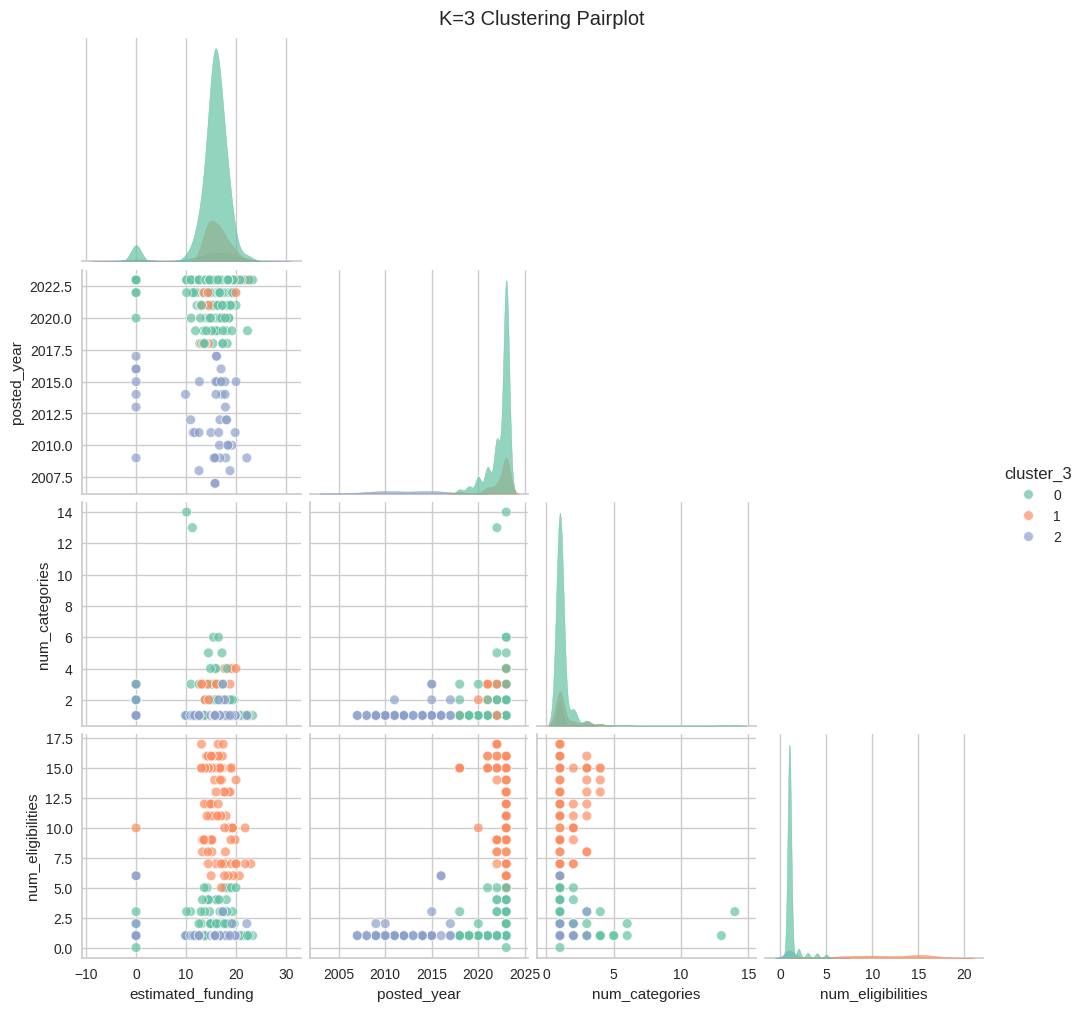

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a dataframe with just the key numeric features and cluster labels
pairplot_data = pd.DataFrame({
    'estimated_funding': merged_ml_clean_simplified['estimated_funding'],
    'posted_year': merged_ml_clean_simplified['posted_year'],
    'cluster_3': merged_ml_clean_simplified['cluster_3']
})

# Add a few category/eligibility features as counts (optional)
pairplot_data['num_categories'] = merged_ml_clean_simplified[category_cols].sum(axis=1)
pairplot_data['num_eligibilities'] = merged_ml_clean_simplified[eligibility_cols].sum(axis=1)

# Create pairplot
sns.pairplot(pairplot_data,
             hue="cluster_3",
             diag_kind="kde",
             corner=True,
             palette="Set2",
             plot_kws={'alpha': 0.7},
             diag_kws={'alpha': 0.7})
plt.suptitle('K=3 Clustering Pairplot', y=1.01)
plt.show()

**Analysis:** This pairplot visualizes the 3 clusters. Here are further analyses:

**Cluster 0 (526 grants): modern science & environment expansion era (2018–2023).** This cluster is tightly concentrated in recent years and shows moderate category and eligibility counts, suggesting large-scale, standardized science and environment programs. Estimated funding is relatively consistent, reflecting mature, institutionalized funding priorities.

**Cluster 1 (112 grants): modern public health & natural resources era (2018–2023).** While temporally overlapping with Cluster 0, this cluster stands out for higher eligibility counts, indicating broader access and multi-stakeholder public health and conservation initiatives. Funding levels are comparable but programs are more policy-driven and inclusive.

**Cluster 2 (47 grants): pre-modern science baseline era (2007–2017).** This cluster is clearly separated by time and shows fewer categories and eligibilities, reflecting narrower and more specialized grants. Lower and more dispersed funding suggests a less centralized, pre-expansion funding landscape, with less data.

###**6.2. Boxplots**

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

###**Estimated Funding by Cluster**

/tmp/ipython-input-3011108157.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_ml_clean_simplified, x='cluster_3', y='estimated_funding', palette='Set2')


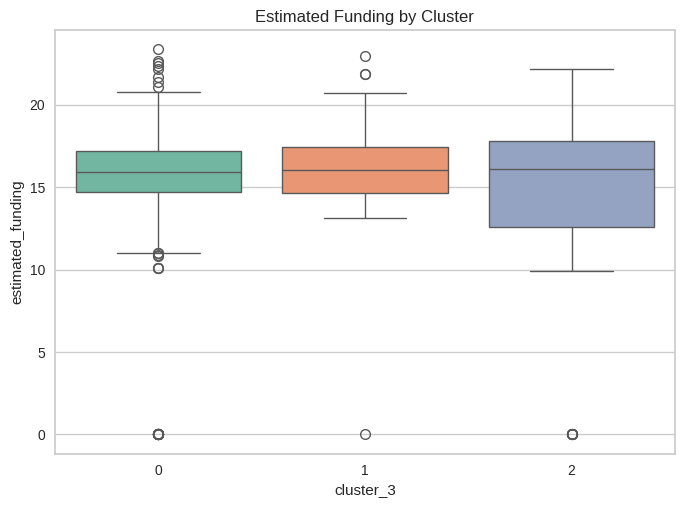

In [47]:
sns.boxplot(data=merged_ml_clean_simplified, x='cluster_3', y='estimated_funding', palette='Set2')
plt.title('Estimated Funding by Cluster')
plt.show()

###**Posted Year by Cluster**

/tmp/ipython-input-4084730220.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_ml_clean_simplified, x='cluster_3', y='posted_year', palette='Set2')


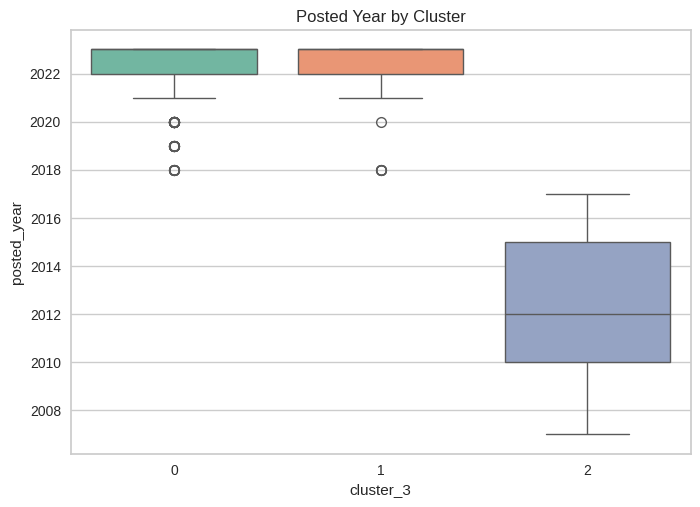

In [48]:
sns.boxplot(data=merged_ml_clean_simplified, x='cluster_3', y='posted_year', palette='Set2')
plt.title('Posted Year by Cluster')
plt.show()

**Analysis:** These boxplots are another way to visualize what we have found, which is that clusters incorporate similar mean/median of estimated funding, and clusters 0 and 1 are both in more recent years, while cluster 2 is older.

**Final overarching analysis:** Ultimately, some "era" clusters did come about from unsupervised machine learning clustering using K-means. One older cluster and two most modern clusters formed. These also had some unique policy priorities. The largest cluster (0) encapsulates more recent grants of science, envrionment, and energy programs. Cluster 1 has high eligibility counts, indicating multi-stakeholder health and conservation initiatives. Cluster 2 was from 2007-2017, and represents mainly science, health, and "other" grants.

Relating to COVID, 2020-time was a clear inflection point when federal grant-making exploded (at least, what was tracked in the Details/Merged table, but this is also reflected in the large Grants funding graph in EDA 2.2). This is especially the case for health, but also broadly across science, education, and environment. My clustering captured this, with the public health-focused cluster (Cluster 1) representing the pandemic response era.

Federal agencies and policy analysts can see how these three clusters correlate to past efficacy, and economic and political trends. For instance, should another health crisis like COVID occur, how can they better allocate funds to lessen health and economic damages? Grant applicants can also use these clusters to make predictive analyses of future funding potential. However, these clusters are not incredibly intricate, limiting the extent of insights they provide. More data over a longer period of time would be optimal.

**AI Disclosure:** My written report includes a link to my conversations with AI chatbot Claude, which helped me figure out optimal code for EDA graphs and clustering, as well as analyzing some findings.